In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import torch
import os

In [2]:
df_default = pd.read_csv('experiment_metrics_fully_parallel/default1.csv')
df_default['Train size'] = '950k'

df_50k = pd.read_csv('experiment_metrics_fully_parallel/train-50k.csv')
df_50k['Train size'] = '50k'

df_5k = pd.read_csv('experiment_metrics_fully_parallel/train-5k.csv')
df_5k['Train size'] = '5k'

df_500 = pd.read_csv('experiment_metrics_fully_parallel/train-500-bs1.csv')
df_500['Train size'] = '500'

mdf = pd.concat([df_default, df_50k, df_5k, df_500], ignore_index=True)
print(mdf.columns)

Index(['val/total_mse', 'train/grad_norm', 'train/forces_magnitude_error',
       'train/lr', 'train/epoch', 'train/energy_mae', '_timestamp',
       'val/forces_mae', 'val/energy_mse', 'train/forces_mse',
       'train/energy_rmse', 'train/energy_forces_within_threshold',
       'val/forces_rmse', 'val/energy_mae', 'train/energy_mse',
       'val/energy_rmse', 'val/forces_cosine_similarity',
       'train/forces_cosine_similarity', 'train/step',
       'val/pct_loss_from_equiv_error', '_runtime', 'train/forces_mae',
       'val/loss', 'val/mean_pred_error', 'val/epoch',
       'val/energy_forces_within_threshold', 'train/loss', 'val/forces_mse',
       'val/forces_magnitude_error', 'train/forces_rmse', '_step',
       'val/equiv_error', 'Train size', 'val/mean_pred_grad_norm',
       'val/grad_norm_ratio_equiv_over_mean', 'val/equiv_grad_norm'],
      dtype='object')


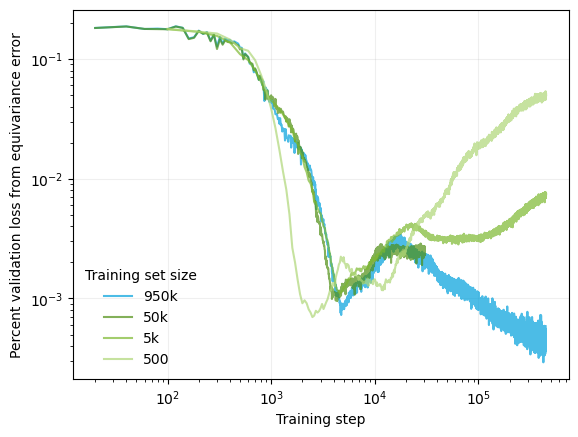

In [5]:
sns.lineplot(
    data=mdf,
    x='_step',
    y='val/pct_loss_from_equiv_error',
    hue = 'Train size',
    palette = {
        '500': '#aed677',
        '5k': '#7cb82f',
        '50k': '#4e8f13',
        '950k': '#00a0dc',
    },
    errorbar = None,
    alpha=0.7,
)

plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)
plt.xlabel('Training step')
plt.ylabel('Percent validation loss from equivariance error')
plt.legend(frameon=False, title = 'Training set size')

plt.savefig('escaip-vary-train-size.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### eda

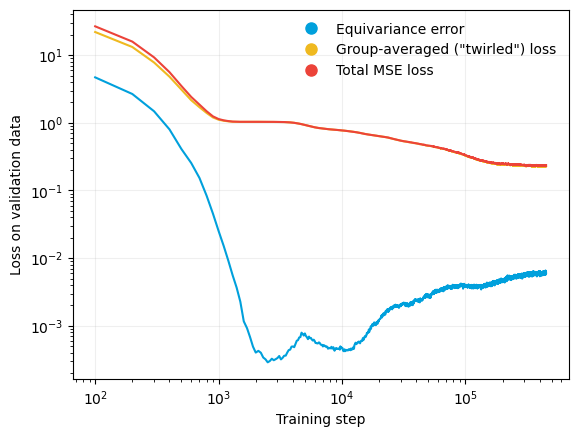

In [18]:
# Loss curves

df = mdf[mdf['Train size'] == '500']

sns.lineplot(
    data=df,
    x='_step',
    y='val/equiv_error',
    label = 'Equivariance error',
    color = '#00a0dc',
    errorbar = None,
)
sns.lineplot(
    data=df,
    x='_step',
    y='val/mean_pred_error',
    label = 'Group-averaged ("twirled") loss',
    color = '#efb920',
    errorbar = None,
)
sns.lineplot(
    data=df,
    x='_step',
    y='val/total_mse',
    color = '#ec4339',
    label = 'Total MSE loss',
    errorbar = None,
)

# sns.despine()
plt.yscale('log')
plt.xscale('log')
plt.grid(alpha = 0.2)


# Create custom Line2D objects to represent legend markers
import matplotlib.lines as mlines
equiv_handle = mlines.Line2D([], [], color='#00a0dc', marker='o', linestyle='None',
                          markersize=8, label='Equivariance error')
twirled_handle = mlines.Line2D([], [], color='#efb920', marker='o', linestyle='None',
                           markersize=8, label='Group-averaged ("twirled") loss')
total_handle = mlines.Line2D([], [], color='#ec4339', marker='o', linestyle='None',
                           markersize=8, label='Total MSE loss')
plt.legend(frameon=False, handles=[equiv_handle, twirled_handle, total_handle])
# plt.legend(frameon=False)


plt.xlabel('Training step')
plt.ylabel('Loss on validation data')

# plt.savefig('escaip-default-losscurves.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()